# Stable Diffusion: Theory & Practice

> **Course:** Computer Vision — Generative Models Module  
> **Prerequisites:** Familiarity with PyTorch, basic probability, and neural networks  
> **Runtime:** GPU recommended (T4 or better on Colab)

---

## Table of Contents

**Theory**

1. [Background: From VAEs to Diffusion](#1-background)
2. [Diffusion Models: The Core Idea](#2-diffusion-theory)
3. [Latent Diffusion Models (LDM)](#3-ldm)
4. [The U-Net Denoiser](#4-unet)
5. [CLIP Text Conditioning](#5-clip)
6. [The Sampling Process](#6-sampling)

**Practice**

7. [Environment Setup](#7-setup)
8. [Practical 1 — Text-to-Image](#8-text2img)
9. [Practical 2 — Image-to-Image](#9-img2img)
10. [Practical 3 — Inpainting](#10-inpainting)
11. [Practical 4 — Prompt Engineering](#11-prompts)
12. [Practical 5 — Visualizing the Denoising Process](#12-denoising-viz)
13. [Advanced: LoRA and Fine-tuning Concepts](#13-lora)
14. [Practical 6 — ControlNet: Structural Conditioning](#14-controlnet)

**Wrap-up**

15. [Exercises](#15-exercises)
16. [What We Switched Off, and What We Borrowed](#16-responsible-use)
17. [References](#17-references)

---
<a name='1-background'></a>
## 1. Background: From VAEs to Diffusion

### Why generative models?

Generative models learn the **data distribution** $p(x)$ and can sample new instances from it. The main families are:

| Model | Core Idea | Strengths | Weaknesses |
|---|---|---|---|
| **VAE** | Encode to latent → decode | Stable training, continuous latent | Blurry outputs |
| **GAN** | Generator vs. Discriminator | Sharp images | Mode collapse, training instability |
| **Normalizing Flow** | A stack of *invertible* maps; density via change of variables | Exact likelihood | Architecture constrained by invertibility; expensive |
| **Diffusion** | Iterative denoising of a fixed noising process | Stable training, very high quality | Slow sampling (improving) |
| **Flow Matching / Rectified Flow** | Learn a velocity field along a *straight* path from noise to data | Same training stability, far fewer sampling steps | Newer; most course material still uses ε-prediction |

> **Two very different things are called "flow".** *Normalizing flows* (Rezende & Mohamed,
> 2015) are the invertible-architecture family in row 3 — largely superseded. *Flow
> matching / rectified flow* (row 5) is a training objective closely related to diffusion,
> and it is what every current frontier open model uses: SD 3/3.5, FLUX.2, Qwen-Image.
> Section 6.1 comes back to this once the diffusion machinery is in place.

### Variational Autoencoders (Brief Recap)

A VAE learns:
- An **encoder** $q_\phi(z|x)$: maps image $x$ to latent distribution $(\mu, \sigma)$
- A **decoder** $p_\theta(x|z)$: reconstructs from sampled latent $z \sim \mathcal{N}(\mu, \sigma^2)$

The ELBO loss:
$$\mathcal{L}_{\text{VAE}} = \underbrace{\mathbb{E}[\log p_\theta(x|z)]}_{\text{reconstruction}} - \underbrace{D_{KL}(q_\phi(z|x) \| p(z))}_{\text{regularization}}$$

**Key takeaway:** VAEs provide a compressed, continuous latent space — a property that Stable Diffusion *reuses* to make diffusion tractable.

---
<a name='2-diffusion-theory'></a>
## 2. Diffusion Models: The Core Idea

Diffusion models are inspired by **non-equilibrium thermodynamics**. The key insight:

> If we know how to *destroy* data by gradually adding noise, we can learn to *reverse* this process and generate data from pure noise.

### 2.1 Forward Process (Noise Schedule)

Given a clean image $x_0$, we define a Markov chain that adds Gaussian noise over $T$ timesteps:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t;\ \sqrt{1 - \beta_t}\, x_{t-1},\ \beta_t \mathbf{I})$$

Where $\{\beta_t\}$ is the **noise schedule** (typically from $\beta_1 \approx 10^{-4}$ to $\beta_T \approx 0.02$).

A beautiful property: we can sample **any** timestep directly:

$$q(x_t | x_0) = \mathcal{N}(x_t;\ \sqrt{\bar{\alpha}_t}\, x_0,\ (1 - \bar{\alpha}_t) \mathbf{I})$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.

So explicitly: $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$, with $\epsilon \sim \mathcal{N}(0, \mathbf{I})$.

### 2.2 Reverse Process (Denoising)

The reverse process is also Gaussian (for small $\beta_t$):

$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1};\ \mu_\theta(x_t, t),\ \Sigma_\theta(x_t, t))$$

A neural network $\epsilon_\theta$ learns to **predict the noise** $\epsilon$ added to $x_0$.

### 2.3 Training Objective

The simplified DDPM loss (Ho et al., 2020):

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t, x_0, \epsilon} \left[ \| \epsilon - \epsilon_\theta(\underbrace{\sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon}_{x_t},\ t) \|^2 \right]$$

**Translation:** At each training step:
1. Sample a clean image $x_0$ from the dataset
2. Sample a random timestep $t$ and noise $\epsilon$
3. Create noisy image $x_t$
4. Ask the network to predict $\epsilon$ from $x_t$ and $t$
5. Minimize prediction error

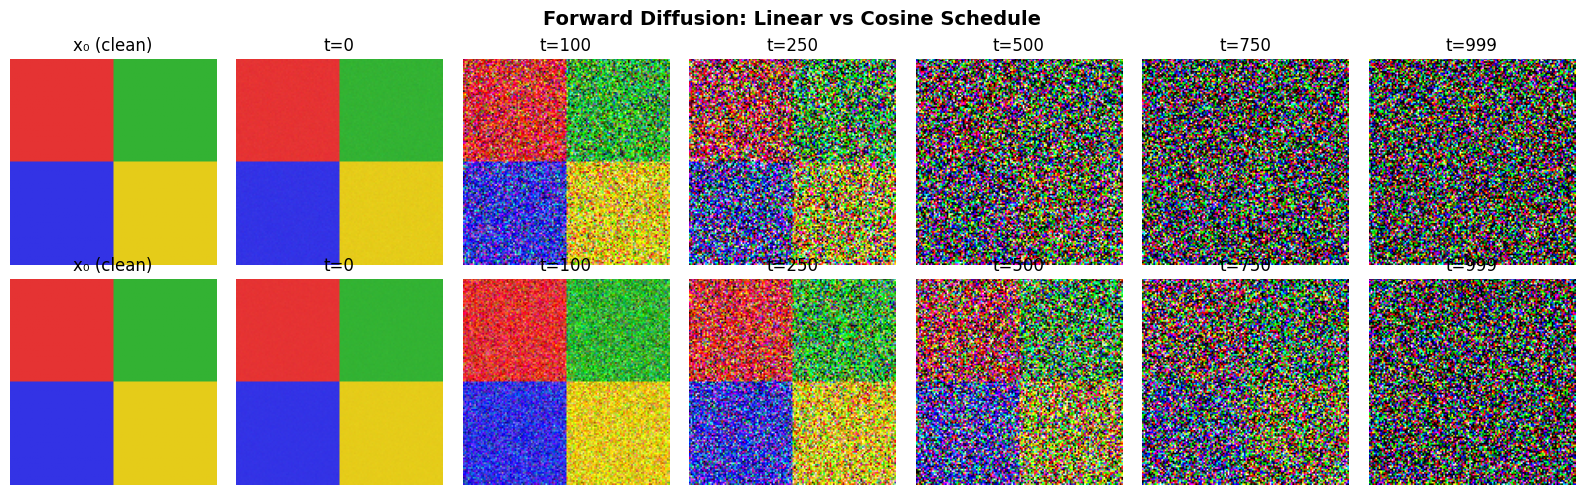

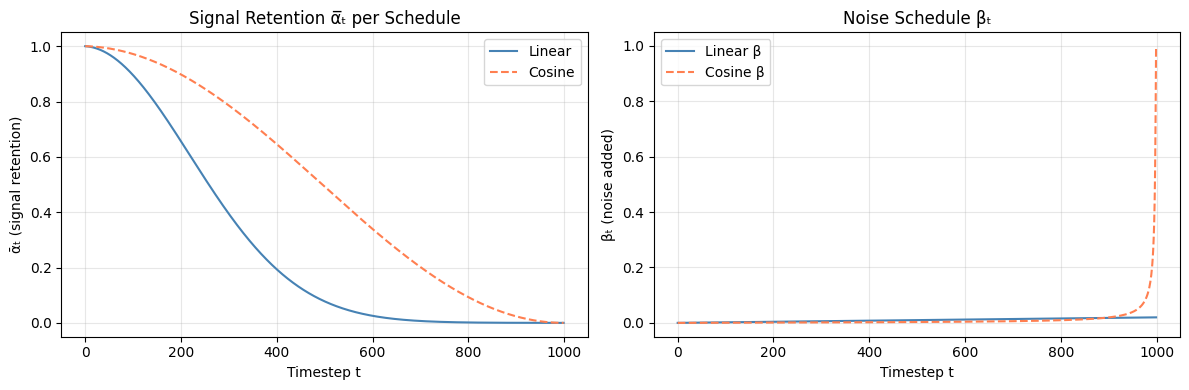


📌 Observation: The cosine schedule adds noise more gradually at the start,
   preserving low-frequency structure longer — leading to better sample quality.


In [1]:
# ── Visualizing the Forward Diffusion Process ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import requests
from io import BytesIO

def get_noise_schedule(T=1000, schedule='linear'):
    """Returns beta_t, alpha_t, alpha_bar_t for a given noise schedule."""
    if schedule == 'linear':
        betas = np.linspace(1e-4, 0.02, T)
    elif schedule == 'cosine':
        # Improved DDPM (Nichol & Dhariwal, 2021)
        s = 0.008
        steps = np.arange(T + 1)
        f = np.cos((steps / T + s) / (1 + s) * np.pi / 2) ** 2
        alphas_bar = f / f[0]
        betas = 1 - alphas_bar[1:] / alphas_bar[:-1]
        betas = np.clip(betas, 0, 0.999)
        alphas = 1 - betas
        alphas_bar = np.cumprod(alphas)
        return betas, alphas, alphas_bar
    alphas = 1 - betas
    alphas_bar = np.cumprod(alphas)
    return betas, alphas, alphas_bar

def forward_diffusion(x0_arr, t, alphas_bar):
    """Apply q(x_t | x_0) directly using the closed-form expression."""
    noise = np.random.randn(*x0_arr.shape)
    alpha_bar_t = alphas_bar[t]
    x_t = np.sqrt(alpha_bar_t) * x0_arr + np.sqrt(1 - alpha_bar_t) * noise
    return np.clip(x_t, 0, 1), noise

# Load a sample image
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png"
try:
    resp = requests.get(url, timeout=5)
    img = Image.open(BytesIO(resp.content)).convert('RGB').resize((128, 128))
    x0 = np.array(img) / 255.0
except:
    # Fallback: generate a synthetic colorful image
    x0 = np.zeros((128, 128, 3))
    x0[:64, :64] = [0.9, 0.2, 0.2]   # red
    x0[:64, 64:] = [0.2, 0.7, 0.2]   # green
    x0[64:, :64] = [0.2, 0.2, 0.9]   # blue
    x0[64:, 64:] = [0.9, 0.8, 0.1]   # yellow

# ── Plot Forward Process ───────────────────────────────────────────────────
T = 1000
betas_lin, alphas_lin, abar_lin   = get_noise_schedule(T, 'linear')
betas_cos, alphas_cos, abar_cos   = get_noise_schedule(T, 'cosine')

timesteps_to_show = [0, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(2, len(timesteps_to_show) + 1, figsize=(16, 5))
fig.suptitle('Forward Diffusion: Linear vs Cosine Schedule', fontsize=14, fontweight='bold')

for row, (abar, label) in enumerate([(abar_lin, 'Linear'), (abar_cos, 'Cosine')]):
    axes[row, 0].set_ylabel(label, fontsize=12, fontweight='bold')
    axes[row, 0].imshow(x0)
    axes[row, 0].set_title('x₀ (clean)')
    axes[row, 0].axis('off')
    for col, t in enumerate(timesteps_to_show):
        xt, _ = forward_diffusion(x0, t, abar)
        axes[row, col + 1].imshow(xt)
        axes[row, col + 1].set_title(f't={t}')
        axes[row, col + 1].axis('off')

plt.tight_layout()
plt.savefig('forward_diffusion.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Plot Schedule Comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t_range = np.arange(T)
axes[0].plot(t_range, abar_lin, label='Linear', color='steelblue')
axes[0].plot(t_range, abar_cos, label='Cosine', color='coral', linestyle='--')
axes[0].set_xlabel('Timestep t'); axes[0].set_ylabel('ᾱₜ (signal retention)')
axes[0].set_title('Signal Retention α̅ₜ per Schedule'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_range, betas_lin, label='Linear β', color='steelblue')
axes[1].plot(t_range, betas_cos, label='Cosine β', color='coral', linestyle='--')
axes[1].set_xlabel('Timestep t'); axes[1].set_ylabel('βₜ (noise added)')
axes[1].set_title('Noise Schedule βₜ'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Observation: The cosine schedule adds noise more gradually at the start,")
print("   preserving low-frequency structure longer — leading to better sample quality.")

---
<a name='3-ldm'></a>
## 3. Latent Diffusion Models (LDM)

### The Scalability Problem

Running diffusion **directly in pixel space** for a 512×512 image means operating on a 786,432-dimensional vector. This is:
- Computationally expensive
- Redundant (most of image information is low-frequency)

### The LDM Solution (Rombach et al., 2022)

Stable Diffusion decouples the process into two stages:

```text
┌─────────────────────────────────────────────────────────────────┐
│  Stage 1: Perceptual Compression (trained once, frozen)         │
│  Image x (512×512×3) ──[VAE Encoder]──► z (64×64×4)             │
│                         ◄[VAE Decoder]── z                      │
│                                                                 │
│  Stage 2: Latent Diffusion (the generative model)               │
│  z₀ ──[Forward]──► zₜ (noisy latent)                             │
│  zₜ + condition c ──[U-Net ε_θ]──► z₀ (denoised latent)          │
│  z₀ ──[VAE Decoder]──► x̂ (generated image)                      │
└─────────────────────────────────────────────────────────────────┘
```

**Compression ratio:** 512×512×3 → 64×64×4, a **48× reduction** in dimensionality!

### Why does this work?

The VAE encoder learns a **perceptually meaningful** compression — it preserves semantic content while discarding imperceptible high-frequency noise. The diffusion model then operates in this *semantic* latent space, making learning easier and inference faster.

### Key Parameters in SD 1.5

| Component | Detail |
|---|---|
| VAE latent channels | 4 |
| Downsampling factor | 8× (per spatial dim) |
| Latent resolution (512 input) | 64×64 |
| Diffusion timesteps T | 1000 (training) |
| Inference steps | 20–50 (with fast samplers) |
| U-Net parameters | ~860M |
| CLIP text encoder | ~123M (CLIP ViT-L/14 text tower) |

> The text-encoder figure is specific to SD 1.x. SD 2.x swapped in the much larger
> **OpenCLIP ViT-H/14** text tower (~354M), which is the main reason the two generations
> respond so differently to the same prompt. The cell that loads the pipeline in Section 7
> prints the real parameter count — check it against this table.

---
<a name='4-unet'></a>
## 4. The U-Net Denoiser Architecture

The denoising network $\epsilon_\theta(z_t, t, c)$ is a **conditional U-Net** with:

### 4.1 Timestep Embedding

Timestep $t$ is encoded via **sinusoidal positional embeddings** (same as Transformers):

$$\text{emb}(t)_i = \begin{cases} \sin(t / 10000^{i/d}) & \text{if } i \text{ even} \\ \cos(t / 10000^{(i-1)/d}) & \text{if } i \text{ odd} \end{cases}$$

Then projected through 2 linear layers into a feature vector added to each ResNet block.

### 4.2 Architecture Overview

```text
Input z_t (64×64×4)
        │
   [Conv 3×3] ─────────────────────────────────────────────────────────────┐
        │                                                                   │
  ┌─────▼──────┐                                                     ┌─────▼──────┐
  │ DownBlock 1│ (ResNet + SelfAttn)  ──────── skip ──────────────► │  UpBlock 1 │
  └─────┬──────┘                                                     └─────┬──────┘
  ┌─────▼──────┐                                                     ┌─────▼──────┐
  │ DownBlock 2│ (ResNet + CrossAttn) ─────── skip ──────────────►  │  UpBlock 2 │
  └─────┬──────┘                                                     └─────┬──────┘
  ┌─────▼──────┐                                                     ┌─────▼──────┐
  │ DownBlock 3│ (ResNet + CrossAttn) ─────── skip ──────────────►  │  UpBlock 3 │
  └─────┬──────┘                                                     └─────┬──────┘
        │
  ┌─────▼──────┐
  │  MidBlock  │ (ResNet + SelfAttn + ResNet)
  └────────────┘
        │
   [Conv 3×3] → predicted noise ε̂ (64×64×4)
```

### 4.3 Cross-Attention for Text Conditioning

At each attention block:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right) V$$

- **Q** (Query): from spatial features of $z_t$  
- **K, V** (Key, Value): from text embeddings $c = \text{CLIP}(\text{prompt})$

This is how the text "controls" the denoising — at every layer, the network attends to the relevant parts of the text embedding.

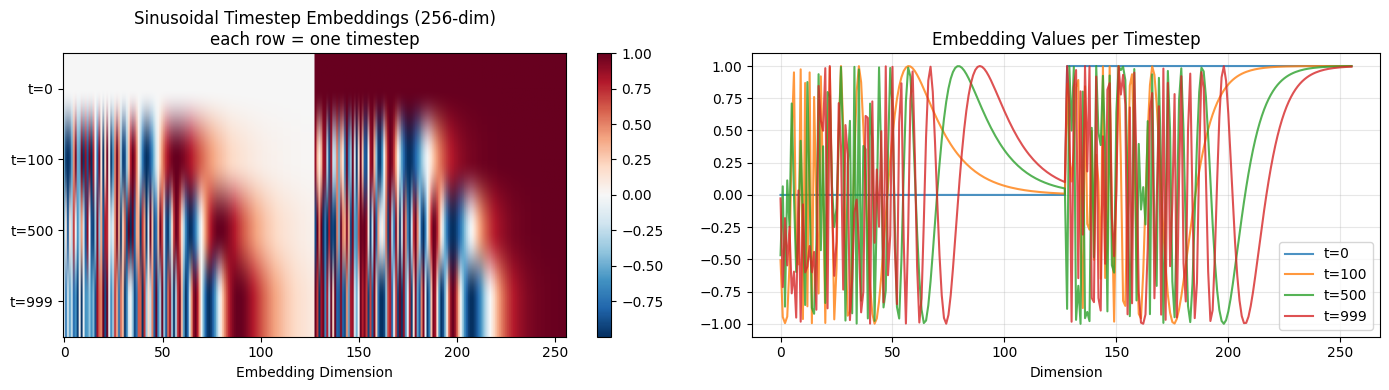

Embedding shape: torch.Size([4, 256]) 
Each timestep has a unique signature for the network.


In [2]:
# ── Minimal U-Net building blocks (educational, not SD's actual code) ──────
import torch
import torch.nn as nn
import math

class SinusoidalPositionEmbedding(nn.Module):
    """Encodes the diffusion timestep t into a vector."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]      # [B, half_dim]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)  # [B, dim]
        return emb

class ResBlock(nn.Module):
    """ResNet block with timestep conditioning."""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1  = nn.Sequential(nn.GroupNorm(8, in_ch), nn.SiLU(), nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.conv2  = nn.Sequential(nn.GroupNorm(8, out_ch), nn.SiLU(), nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]  # broadcast over H, W
        h = self.conv2(h)
        return h + self.residual(x)

class CrossAttention(nn.Module):
    """Cross-attention: queries from image features, keys/values from text."""
    def __init__(self, query_dim, context_dim, heads=8):
        super().__init__()
        self.heads = heads
        self.scale = (query_dim // heads) ** -0.5
        self.to_q = nn.Linear(query_dim, query_dim, bias=False)
        self.to_k = nn.Linear(context_dim, query_dim, bias=False)
        self.to_v = nn.Linear(context_dim, query_dim, bias=False)
        self.to_out = nn.Linear(query_dim, query_dim)

    def forward(self, x, context):
        B, N, C = x.shape
        H = self.heads
        q = self.to_q(x).reshape(B, N, H, C // H).transpose(1, 2)
        k = self.to_k(context).reshape(B, -1, H, C // H).transpose(1, 2)
        v = self.to_v(context).reshape(B, -1, H, C // H).transpose(1, 2)
        attn = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * self.scale, dim=-1)
        out = torch.matmul(attn, v).transpose(1, 2).reshape(B, N, C)
        return self.to_out(out)

# ── Demonstrate timestep embedding ────────────────────────────────────────
emb_module = SinusoidalPositionEmbedding(dim=256)
timesteps = torch.tensor([0, 100, 500, 999])
embeddings = emb_module(timesteps)  # [4, 256]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(embeddings.detach().numpy(), aspect='auto', cmap='RdBu_r')
axes[0].set_title('Sinusoidal Timestep Embeddings (256-dim)\neach row = one timestep')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_yticks([0,1,2,3]); axes[0].set_yticklabels(['t=0','t=100','t=500','t=999'])
plt.colorbar(im, ax=axes[0])

axes[1].plot(embeddings[0].detach(), label='t=0', alpha=0.8)
axes[1].plot(embeddings[1].detach(), label='t=100', alpha=0.8)
axes[1].plot(embeddings[2].detach(), label='t=500', alpha=0.8)
axes[1].plot(embeddings[3].detach(), label='t=999', alpha=0.8)
axes[1].set_title('Embedding Values per Timestep')
axes[1].set_xlabel('Dimension'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Embedding shape:", embeddings.shape, "\nEach timestep has a unique signature for the network.")

---
<a name='5-clip'></a>
## 5. CLIP Text Conditioning

### What is CLIP?

**Contrastive Language-Image Pretraining** (Radford et al., 2021) trains two encoders jointly:
- A **text encoder** (Transformer)
- An **image encoder** (ViT or ResNet)

...to maximize similarity of matching image-text pairs in a shared embedding space.

SD 1.5 uses only the **text tower** of `openai/clip-vit-large-patch14` (~123M parameters);
the image tower is not part of the pipeline at all.

### How Stable Diffusion Uses CLIP

1. Your prompt → **CLIP Tokenizer** → token IDs (max 77 tokens)
2. Token IDs → **CLIP Text Transformer** → text embeddings $c \in \mathbb{R}^{77 \times 768}$
3. Embeddings $c$ are passed as **Key** and **Value** in every cross-attention layer of the U-Net

### Classifier-Free Guidance (CFG)

To strengthen adherence to the prompt, SD uses **Classifier-Free Guidance**:

$$\hat{\epsilon}_\theta(z_t, c) = \epsilon_\theta(z_t, \varnothing) + w \cdot (\epsilon_\theta(z_t, c) - \epsilon_\theta(z_t, \varnothing))$$

Where:
- $\varnothing$ = unconditional embedding (empty prompt or `""`)  
- $c$ = text embedding of your prompt  
- $w$ = **guidance scale** (typically 7.5)

**Interpretation:** We move the prediction *away* from "no prompt" and *toward* the target prompt, scaled by $w$. Higher $w$ → stronger prompt adherence but less diversity.

| Guidance Scale | Effect |
|---|---|
| 1.0 | No guidance (pure model prior) |
| 3–5 | Loose adherence, creative |
| 7–9 | Balanced (default) |
| 12–20 | Strong adherence, potential artifacts |

### 5.1 Corollary: the negative prompt **is** $\varnothing$

`negative_prompt` looks like a separate feature in the pipeline's argument list, but it is
not a separate mechanism. There is only one CFG equation, and the negative prompt simply
replaces the empty string in the unconditional term:

$$\hat{\epsilon} = \epsilon_\theta(z_t, c_{\text{neg}}) + w \cdot \big(\epsilon_\theta(z_t, c) - \epsilon_\theta(z_t, c_{\text{neg}})\big)$$

Two consequences that explain most confusion about it:

- **Guidance pushes *away* from $c_{\text{neg}}$ along the same vector it pushes *toward*
  $c$.** Writing `"blurry, watermark"` does not filter anything out; it moves the
  prediction in the direction opposite to the model's idea of "blurry, watermark".
- **At $w = 1.0$ the negative prompt is completely inert.** Substituting $w=1$ collapses
  the equation to $\hat{\epsilon} = \epsilon_\theta(z_t, c)$ — the $c_{\text{neg}}$ terms
  cancel exactly. `diffusers` knows this and skips the unconditional forward pass entirely
  when `guidance_scale <= 1`, which is also why that setting is roughly twice as fast.
  The `CFG = 1.0` column in the next section is that case.
- Both branches are batched into a single U-Net call, so CFG costs **2× the compute** of an
  unguided step. That is the price of every image in this notebook.

---
<a name='6-sampling'></a>
## 6. The Sampling Process — DDIM & PNDM

### DDPM Sampling (Slow)

The original sampling from Ho et al. requires all $T=1000$ reverse steps:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t, t)\right) + \sigma_t z$$

### DDIM Sampling (Fast, Deterministic)

Denoising Diffusion Implicit Models (Song et al., 2020) reformulate as a non-Markovian process, allowing **arbitrary step skipping**:

$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \underbrace{\left(\frac{x_t - \sqrt{1-\bar{\alpha}_t}\, \epsilon_\theta}{\sqrt{\bar{\alpha}_t}}\right)}_{\text{predicted } x_0} + \underbrace{\sqrt{1-\bar{\alpha}_{t-1} - \sigma_t^2}\, \epsilon_\theta}_{\text{direction to } x_t} + \underbrace{\sigma_t z}_{\text{noise}}$$

Setting $\sigma_t = 0$ makes sampling **fully deterministic** — same seed → same image.

### Sampler Comparison — for ε-prediction models (SD 1.x / 2.x / XL)

Every sampler below solves the *same* reverse SDE/ODE for a network trained to predict
$\epsilon$. They are not interchangeable with the flow-matching samplers of Section 6.1 —
those integrate a different differential equation.

| Sampler | Steps | Deterministic | Notes |
|---|---|---|---|
| DDPM | 1000 | No | Original, slow |
| DDIM | 20–50 | Yes | Fast, good quality |
| PNDM | 20–50 | Yes | Better quality than DDIM |
| DPM-Solver++ | 10–20 | Yes | Best speed/quality among ε-prediction solvers |
| Euler Ancestral | 20–30 | No | Creative, varied outputs |

### 6.1 Where the field went next: flow matching / rectified flow

Everything above assumes the ε-prediction formulation this class teaches. Since 2024 the
frontier open models are trained differently: **rectified flow** (*Scaling Rectified Flow
Transformers for High-Resolution Image Synthesis*, arXiv 2403.03206) replaces the curved,
variance-preserving diffusion path with a **straight line** between noise and data,
$z_t = (1-t)\,x_0 + t\,\epsilon$, and trains the network to predict the constant
**velocity** $v = \epsilon - x_0$ rather than the noise.

Because the trajectory is (nearly) straight, an ODE solver needs far fewer steps to follow
it without error — which is why these models sample well at very low step counts. SD 3/3.5,
FLUX.2 and Qwen-Image all use it, and `diffusers` ships the `FlowMatch*` schedulers as
first-class citizens.

SD 1.5 remains the right thing to *learn* on: it is small, unrestricted, and every
component (VAE, U-Net, CLIP, CFG, scheduler) is separable and inspectable. Just know that
"the noise schedule" and "predict ε" are properties of *this generation* of models, not of
generative diffusion as such.

---
<a name='7-setup'></a>
## 7. Environment Setup

We use Hugging Face `diffusers` — the standard library for working with diffusion models.

> ⚠️ **GPU Required:** Go to **Runtime → Change runtime type → T4 GPU** before proceeding.

In [3]:
# ── Install dependencies ────────────────────────────────────────────────────
# Pinned to the versions this class was last verified against (2026-08).
# Why each one:
#   diffusers    — the pipelines; 0.39.0 is the version every API call below matches.
#   peft         — REQUIRED, not optional: every LoRA method in diffusers is guarded by
#                  `if not USE_PEFT_BACKEND: raise ValueError(...)`, and that flag is only
#                  True when peft>=0.6 imports. peft is *not* a diffusers install
#                  dependency (it sits under the `training` extra), so Section 13 crashes
#                  on its first line without this line.
#   transformers — CLIP tokenizer + text encoder. Capped below 6 because diffusers
#                  declares only a lower bound and 5.x → 6.x is a major boundary.
#   accelerate   — device placement / offload helpers used by from_pretrained.
# Deliberately NOT installed: xformers. SD 1.5 fp16 fits in ~4 GB, PyTorch's SDPA is
# already the fused-attention default, and the wheel can force a multi-GB torch
# reinstall. See the note in the pipeline cell below.
# Do NOT add torch/torchvision here — Colab's builds are CUDA-matched and PyPI wheels
# break the GPU runtime.
!pip install -q "diffusers==0.39.0" "peft==0.20.0" "transformers>=5.14,<6" "accelerate>=1.0" safetensors

import torch
import warnings
warnings.filterwarnings('ignore')

import diffusers, transformers, peft
print(f"diffusers {diffusers.__version__} · transformers {transformers.__version__} · peft {peft.__version__}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype  = torch.float16 if device == 'cuda' else torch.float32

print(f"✅ Device : {device}")
if device == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected. Some cells will be slow or skipped.")

diffusers 0.39.0 · transformers 5.15.0 · peft 0.20.0
✅ Device : cuda
   GPU    : NVIDIA L4
   VRAM   : 23.7 GB


In [4]:
# ── Load SD 1.5 pipeline ────────────────────────────────────────────────────
# This downloads ~2.5 GB of model weights on first run and caches them.
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# The original `runwayml/*` organisation was withdrawn from the Hub in 2024 — its model
# card 401s and only a courtesy redirect keeps the old id working. Use the canonical
# community-maintained mirror of the same weights:
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,    # disabled for teaching — see Section 16 for what this turns off
)

# Swap to a fast scheduler
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

# ── Note on "memory optimizations" ──────────────────────────────────────────
# SD 1.5 in fp16 needs roughly 4 GB of VRAM, so on Colab's 16 GB T4 nothing here needs
# to be traded away for memory, and the usual two lines are actively harmful:
#   * enable_attention_slicing()  — the diffusers docstring warns "Don't enable attention
#     slicing if you're already using SDPA from PyTorch > 2.0 or xFormers ... it can lead
#     to serious slow downs!". SDPA has been the default attention backend since torch 2.0,
#     so slicing only splits an already-fused kernel into chunks.
#   * enable_xformers_memory_efficient_attention() — redundant for the same reason, and
#     the xformers wheel can drag in a multi-GB torch reinstall.
# If you ever *do* hit an OOM (e.g. batching many 768×768 images), reach for
# pipe.enable_model_cpu_offload() instead, and only then.

print("\n✅ Pipeline loaded successfully!")
print(f"   Scheduler : {pipe.scheduler.__class__.__name__}")
print(f"   VAE       : {pipe.vae.__class__.__name__}")
print(f"   U-Net     : {sum(p.numel() for p in pipe.unet.parameters()) / 1e6:.0f}M params")
print(f"   CLIP      : {sum(p.numel() for p in pipe.text_encoder.parameters()) / 1e6:.0f}M params")
print("   ↑ compare these two numbers with the table in Section 3 — the text encoder is")
print("     the CLIP ViT-L/14 *text tower* (~123M), not the ~340M OpenCLIP tower of SD 2.x.")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



✅ Pipeline loaded successfully!
   Scheduler : DPMSolverMultistepScheduler
   VAE       : AutoencoderKL
   U-Net     : 860M params
   CLIP      : 123M params
   ↑ compare these two numbers with the table in Section 3 — the text encoder is
     the CLIP ViT-L/14 *text tower* (~123M), not the ~340M OpenCLIP tower of SD 2.x.


---
<a name='8-text2img'></a>
## 8. Practical 1 — Text-to-Image Generation

The simplest use case: a text prompt → a generated image.

**Anatomy of a call:**
```
pipe(
    prompt            → positive text description
    negative_prompt   → what to avoid
    num_inference_steps → denoising steps (quality vs speed)
    guidance_scale    → CFG weight w
    generator         → torch.Generator for reproducibility
    height / width    → output resolution (must be multiples of 8)
)
```

  0%|          | 0/25 [00:00<?, ?it/s]

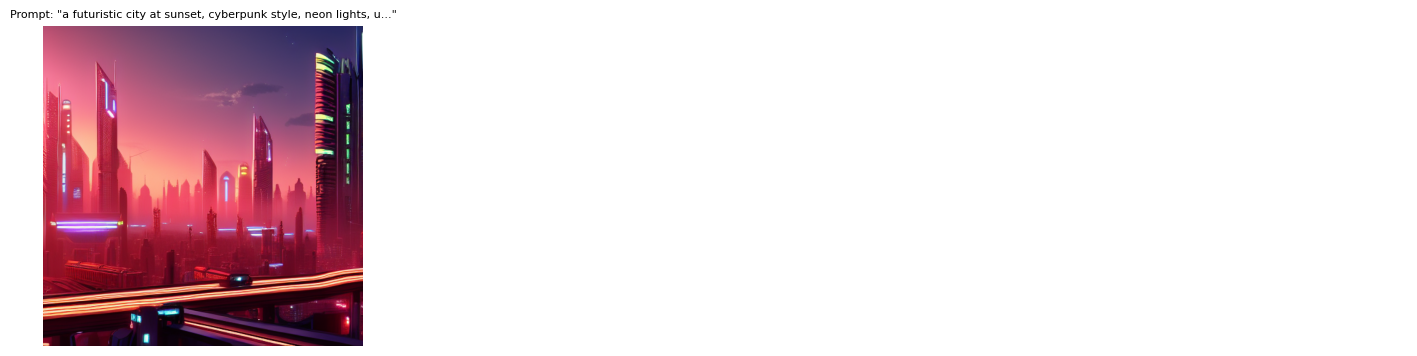

In [5]:
import torch
import matplotlib.pyplot as plt
from PIL import Image # Added for explicit Image conversion
import numpy as np # Added for type checking

def show_images(images, titles=None, cols=4, figsize=None):
    n = len(images)
    rows = (n + cols - 1) // cols
    figsize = figsize or (cols * 3.5, rows * 3.5)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Ensure axes is a flat iterable of AxesSubplot objects
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    elif isinstance(axes, plt.Axes): # Single axis object case (rows=1, cols=1)
        axes = [axes]
    else:
        axes = [] # Should not happen, but for robustness

    # If fewer images than subplots, use only the necessary axes
    if n < len(axes):
        axes = axes[:n]

    for i, (ax, img) in enumerate(zip(axes, images)):
        # Ensure img is a PIL Image object before displaying
        if isinstance(img, np.ndarray):
            # Assuming image data is in [0, 1] range for float arrays
            if img.dtype == np.float32 or img.dtype == np.float64:
                img = (img * 255).astype(np.uint8)
            img = Image.fromarray(img)
        ax.imshow(img)
        ax.axis('off')
        if titles: ax.set_title(titles[i], fontsize=8)

    # Turn off any remaining empty axes if n < len(axes_all)
    # (axes_all refers to the original full set of axes from plt.subplots)
    # This part needs to be careful not to re-iterate on the potentially sliced 'axes'
    # Let's ensure all axes created by subplots are turned off if not used
    all_axes_from_subplots = plt.gcf().get_axes() # Get all axes from the current figure
    for ax_full in all_axes_from_subplots:
        if ax_full not in axes: # If an axis is not used for an image
            ax_full.axis('off')

    plt.tight_layout()
    plt.show()

SEED = 42
generator = torch.Generator(device=device).manual_seed(SEED)

prompt = "a futuristic city at sunset, cyberpunk style, neon lights, ultra-detailed, 4k"
negative_prompt = "blurry, low quality, distorted, watermark, text"

with torch.inference_mode():
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=25,
        guidance_scale=7.5,
        generator=generator,
        height=512, width=512,
    )

image = result.images[0]
show_images([image], titles=[f'Prompt: "{prompt[:60]}..."'])

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

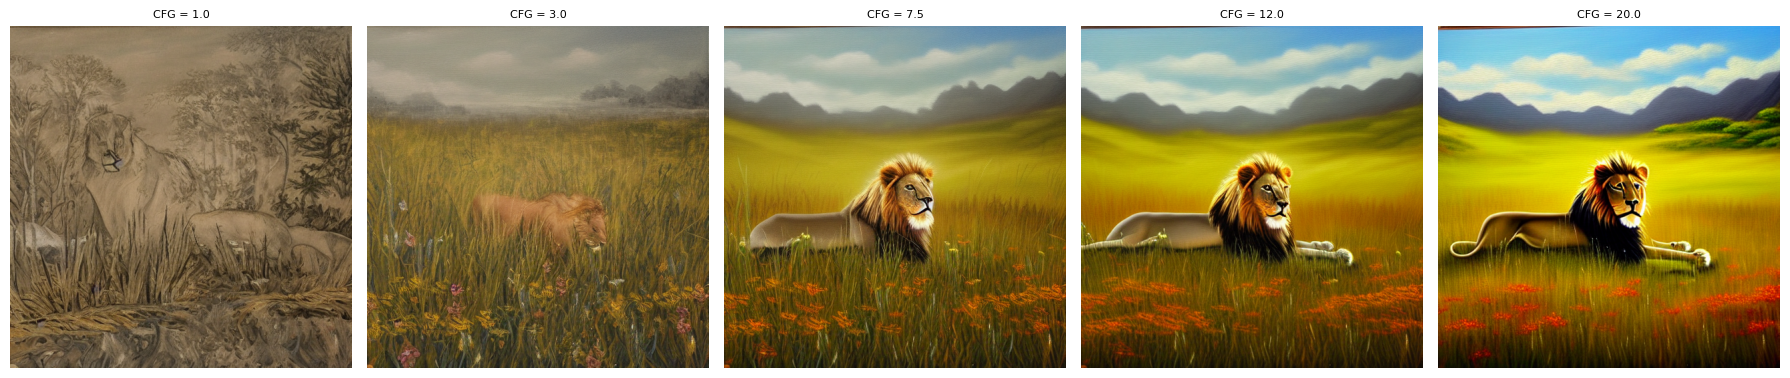


📌 Notice: CFG=1 ignores the prompt; high CFG oversaturates/distorts.
   Try re-running the CFG=1.0 case with a negative_prompt — the output is identical.


In [6]:
# ── Effect of Guidance Scale ─────────────────────────────────────────────────
# Demonstrates how CFG scale controls prompt adherence vs. diversity.
# No negative_prompt is passed here on purpose: at w = 1.0 the CFG formula collapses to
# ε̂ = ε(z, c), the unconditional branch drops out, and a negative prompt would be inert.
# diffusers also skips the unconditional forward pass entirely when guidance_scale <= 1,
# which is why the CFG=1.0 column is about twice as fast as the others.

prompt = "a majestic lion in a meadow, oil painting style"
guidance_scales = [1.0, 3.0, 7.5, 12.0, 20.0]
images, titles = [], []

for w in guidance_scales:
    g = torch.Generator(device=device).manual_seed(SEED)
    with torch.inference_mode():
        img = pipe(prompt=prompt, guidance_scale=w, num_inference_steps=25,
                   generator=g, height=512, width=512).images[0]
    images.append(img)
    titles.append(f'CFG = {w}')

show_images(images, titles=titles, cols=5, figsize=(18, 4))
print("\n📌 Notice: CFG=1 ignores the prompt; high CFG oversaturates/distorts.")
print("   Try re-running the CFG=1.0 case with a negative_prompt — the output is identical.")

---
<a name='9-img2img'></a>
## 9. Practical 2 — Image-to-Image

### Theory

Instead of starting from pure noise $z_T \sim \mathcal{N}(0, I)$, we:
1. Encode the input image → latent $z_0$
2. Add noise only up to step $t^* = T \cdot \text{strength}$ (i.e., partial forward diffusion)
3. Run the reverse process from $z_{t^*}$ (not from $z_T$)

**`strength`** controls how much the output differs from the input:
- `strength=0.0` → identical to input
- `strength=1.0` → effectively text-to-image (fully redrawn)
- `strength=0.5-0.75` → style transfer / guided editing

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

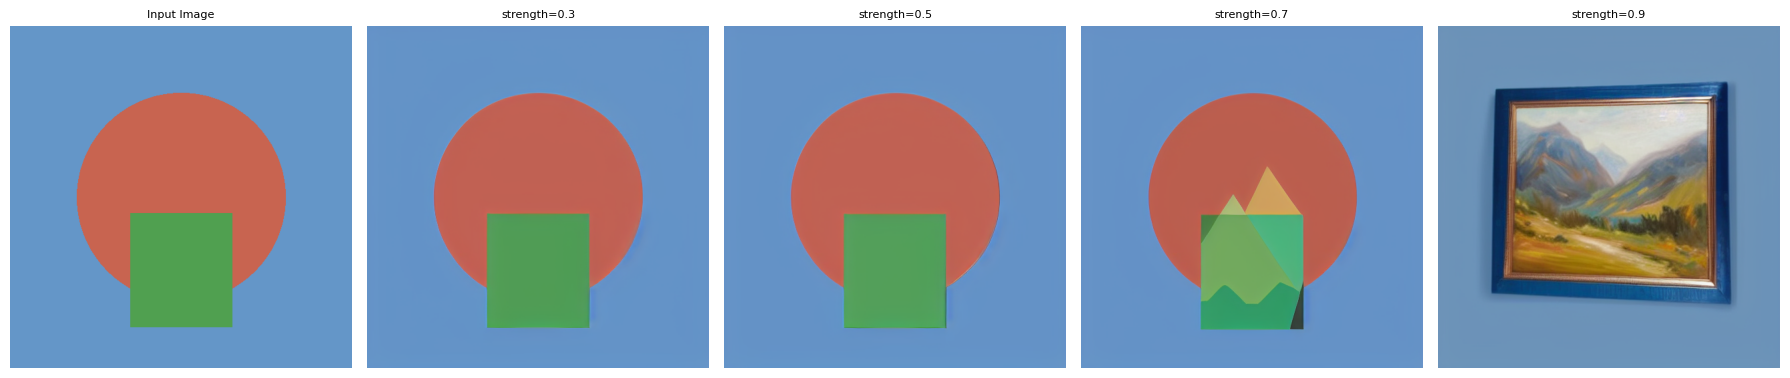


📌 Larger strength → more creative deviation from input.


In [7]:
# ── Image-to-Image ──────────────────────────────────────────────────────────
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import requests
from io import BytesIO

# Load img2img pipeline (reuses weights from memory)
img2img_pipe = StableDiffusionImg2ImgPipeline(
    vae=pipe.vae, text_encoder=pipe.text_encoder,
    tokenizer=pipe.tokenizer, unet=pipe.unet,
    scheduler=pipe.scheduler, safety_checker=None,
    feature_extractor=None, requires_safety_checker=False
).to(device)

# Create or load an input image (simple colored rectangles as fallback)
from PIL import ImageDraw
init_img = Image.new('RGB', (512, 512), color=(100, 150, 200))
draw = ImageDraw.Draw(init_img)
draw.ellipse([100, 100, 412, 412], fill=(200, 100, 80))
draw.rectangle([180, 280, 332, 450], fill=(80, 160, 80))

strengths = [0.3, 0.5, 0.7, 0.9]
prompt = "a detailed oil painting of a landscape with mountains"
images = [init_img]
titles = ['Input Image']

for s in strengths:
    g = torch.Generator(device=device).manual_seed(SEED)
    with torch.inference_mode():
        out = img2img_pipe(
            prompt=prompt, image=init_img,
            strength=s, guidance_scale=7.5,
            num_inference_steps=30, generator=g
        ).images[0]
    images.append(out)
    titles.append(f'strength={s}')

show_images(images, titles=titles, cols=5, figsize=(18, 4))
print("\n📌 Larger strength → more creative deviation from input.")

---
<a name='10-inpainting'></a>
## 10. Practical 3 — Inpainting

### Theory

Inpainting regenerates content inside a **masked region** while conditioning on everything
outside it. The mask (white = regenerate, black = keep) is passed to the pipeline, and at
every denoising step the U-Net input is the concatenation of **9 channels**:

| Channels | What they are |
|---|---|
| 4 | the **noisy latent** $z_t$ — the thing being denoised, exactly as in text-to-image |
| 1 | the **mask**, downsampled to the 64×64 latent grid |
| 4 | the **masked-image latent**: VAE-encode the input image with the masked region blanked out |

```
unet_input = cat([ z_t (4) , mask (1) , masked_image_latent (4) ], dim=1)   # → 9 channels
```

Two things students routinely get wrong here:

1. **The first four channels are $z_t$, not $x_0$.** If the clean latent of the original
   image were fed in, the model would simply copy it — the target would leak into the input.
2. **The U-Net denoises the *entire* latent at every step.** Nothing is excluded from
   diffusion; the mask and the masked-image latent are *conditioning signals* that tell the
   network which region it must invent and what the surroundings look like. This is why
   inpainting can and does shift pixels slightly outside the mask, and why a hard paste-back
   of the original outside the mask is a separate, optional post-processing step.

   (The older "legacy" approach — re-noise the original latent each step and paste it over
   the unmasked area — is a *different* method, and the one that really does freeze the
   background. It works with a plain 4-channel U-Net but produces visible seams.)

Because of the extra 5 channels, inpainting needs its **own checkpoint**: the base SD 1.5
U-Net has `in_channels = 4` and cannot accept this input. The inpainting checkpoint was
fine-tuned from SD 1.5 with a widened first convolution (`in_channels = 9`).

This is used for object removal, replacement, and image editing.

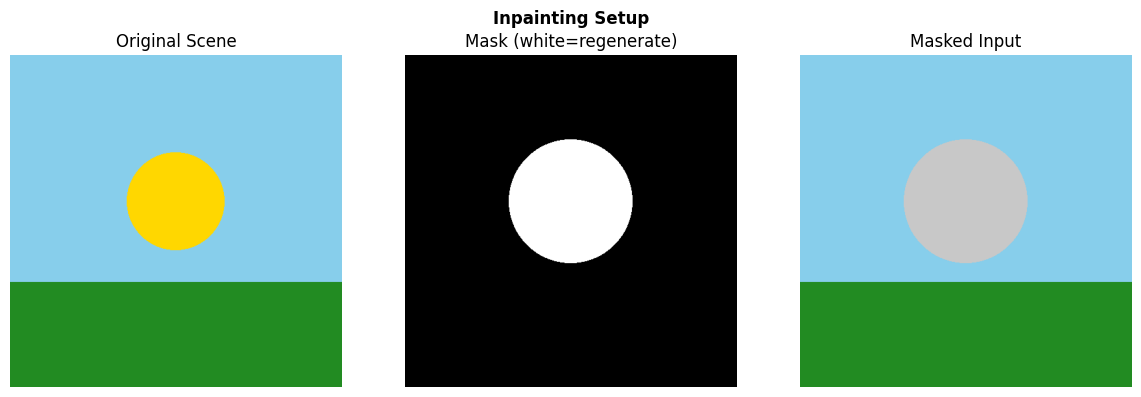


📌 Inpainting concept demonstrated.
   To run actual inpainting, load: 'stable-diffusion-v1-5/stable-diffusion-inpainting'
   with StableDiffusionInpaintPipeline and pass (image=scene, mask_image=mask):

   inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
       INPAINT_MODEL_ID, torch_dtype=dtype, safety_checker=None
   ).to(device)
   out = inpaint_pipe(prompt="a full moon in a night sky",
                      image=scene, mask_image=mask,
                      num_inference_steps=30, guidance_scale=7.5).images[0]

   Check inpaint_pipe.unet.config.in_channels — it is 9, not 4.


In [8]:
# ── Inpainting ──────────────────────────────────────────────────────────────
# For proper inpainting we need a separate checkpoint whose U-Net accepts 9 input
# channels — the base SD 1.5 U-Net only accepts 4 and will raise on the concatenation.
# NOTE: if VRAM is tight, skip the inpaint_pipe load and read the conceptual demo below.
from diffusers import StableDiffusionInpaintPipeline
import numpy as np

# The original `runwayml/stable-diffusion-inpainting` repo was withdrawn in 2024;
# this is the community-maintained mirror of the same weights.
INPAINT_MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-inpainting"

# Create a synthetic scene + mask
scene = Image.new('RGB', (512, 512), (135, 206, 235))   # sky blue
draw = ImageDraw.Draw(scene)
draw.rectangle([0, 350, 512, 512], fill=(34, 139, 34))  # green ground
draw.ellipse([180, 150, 330, 300], fill=(255, 215, 0))  # yellow sun

# Mask: white over the sun region → will be inpainted
mask = Image.new('L', (512, 512), 0)  # black = keep
mask_draw = ImageDraw.Draw(mask)
mask_draw.ellipse([160, 130, 350, 320], fill=255)       # white = regenerate

# Show scene and mask
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(scene); axes[0].set_title('Original Scene'); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Mask (white=regenerate)'); axes[1].axis('off')

# Composite: show what will be kept
composite = np.array(scene).copy()
composite[np.array(mask) > 128] = [200, 200, 200]
axes[2].imshow(composite); axes[2].set_title('Masked Input'); axes[2].axis('off')
plt.suptitle('Inpainting Setup', fontweight='bold'); plt.tight_layout(); plt.show()

print("\n📌 Inpainting concept demonstrated.")
print(f"   To run actual inpainting, load: '{INPAINT_MODEL_ID}'")
print("   with StableDiffusionInpaintPipeline and pass (image=scene, mask_image=mask):")
print("""
   inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
       INPAINT_MODEL_ID, torch_dtype=dtype, safety_checker=None
   ).to(device)
   out = inpaint_pipe(prompt="a full moon in a night sky",
                      image=scene, mask_image=mask,
                      num_inference_steps=30, guidance_scale=7.5).images[0]
""")
print("   Check inpaint_pipe.unet.config.in_channels — it is 9, not 4.")

---
<a name='11-prompts'></a>
## 11. Practical 4 — Prompt Engineering

Prompt crafting is an art. CLIP was trained on internet text, so it responds to photography and art vocabulary.

### Anatomy of a Good Prompt

```
[Subject] [Modifier] [Style] [Artist reference] [Quality tokens] [Technical specs]

Example:
"a medieval knight ← subject
 standing in a foggy forest, dramatic lighting ← modifiers
 digital art, concept art ← style
 by Greg Rutkowski ← artist reference
 highly detailed, sharp focus ← quality tokens
 8k, trending on ArtStation" ← technical specs
```

> **On the "artist reference" slot.** Naming a living artist works because that artist's
> work was in the training set (LAION-5B), scraped without their consent. It is a
> technique with a real cost attached, and Section 16 discusses what that cost is before
> you use it in anything you publish. We keep the example here because you will meet it
> in every prompt guide you read — not as a recommendation.

### Token Weighting (**not** available in this pipeline)

You will constantly see this syntax in prompt guides and on Civitai:

- `(word)` — slight boost
- `(word:1.5)` — 50% more weight
- `[word]` — slight reduction

**None of it does anything here.** That syntax belongs to AUTOMATIC1111 / ComfyUI, which
parse the prompt string themselves before encoding. `StableDiffusionPipeline` hands the
raw string straight to the CLIP tokenizer, so `(`, `)`, `:` and `1.5` are tokenized as
literal characters — they change the embedding a little (in the wrong direction) and eat
part of your 77-token budget. `[word]` is A1111-only and has no meaning at all outside it.

### How to actually weight tokens with `diffusers`

Weighting happens **after** encoding: build the `77 × 768` embedding yourself, scale the
rows belonging to the tokens you want to emphasize, and pass it as `prompt_embeds=`
instead of `prompt=`.

```python
# Minimal illustration of the mechanism (one token, scaled by 1.4)
tok = pipe.tokenizer
ids = tok("a castle on a cliff, stormy sky", padding="max_length",
          max_length=tok.model_max_length, truncation=True,
          return_tensors="pt").input_ids.to(device)

with torch.no_grad():
    embeds = pipe.text_encoder(ids)[0]          # [1, 77, 768]

target = tok.encode("stormy", add_special_tokens=False)[0]
mask   = (ids[0] == target)
embeds[0, mask] *= 1.4                          # emphasize that token's rows

img = pipe(prompt_embeds=embeds, num_inference_steps=25, guidance_scale=7.5).images[0]
```

In practice use a library that does this properly — the `diffusers` guide points at
[`sd_embed`](https://huggingface.co/docs/diffusers/main/en/using-diffusers/weighted_prompts),
which implements the full A1111 weighting grammar on top of `prompt_embeds`. As a bonus it
also **lifts the 77-token limit**, by chunking the prompt into several 77-token windows and
concatenating their embeddings along the sequence axis — something the plain `prompt=`
path cannot do (it just truncates and warns).

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

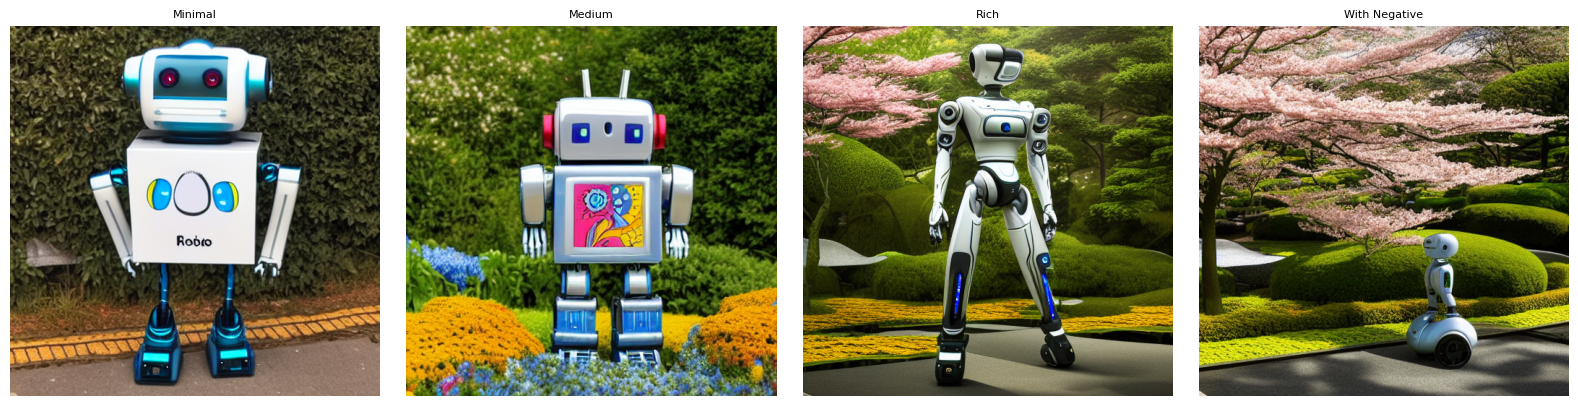


📌 Read this as an illustration, not as a result. It is four images from one seed,
   judged by eye — that cannot separate 'the prompt was better' from 'this seed was
   luckier'. Exercise 7 turns the comparison into a measurement (CLIPScore over
   20 images × 5 seeds per strategy, reported as mean ± std).


In [9]:
# ── Prompt Comparison Experiment ────────────────────────────────────────────
experiments = [
    {
        'label': 'Minimal',
        'prompt': 'a robot'
    },
    {
        'label': 'Medium',
        'prompt': 'a friendly robot in a garden, colorful, detailed'
    },
    {
        'label': 'Rich',
        'prompt': 'a sleek futuristic robot standing in a lush japanese garden, cherry blossoms, soft morning light, highly detailed, photorealistic, 4k, trending on ArtStation'
    },
    {
        'label': 'With Negative',
        'prompt': 'a sleek futuristic robot standing in a lush japanese garden, cherry blossoms, soft morning light, highly detailed, photorealistic, 4k',
        'negative': 'ugly, deformed, low quality, blurry, watermark, extra limbs'
    },
]

results = []
for exp in experiments:
    g = torch.Generator(device=device).manual_seed(SEED)
    neg = exp.get('negative', '')
    with torch.inference_mode():
        img = pipe(
            prompt=exp['prompt'], negative_prompt=neg,
            num_inference_steps=25, guidance_scale=7.5,
            generator=g, height=512, width=512
        ).images[0]
    results.append((img, exp['label']))

show_images([r[0] for r in results], titles=[r[1] for r in results], cols=4, figsize=(16, 4))
print("\n📌 Read this as an illustration, not as a result. It is four images from one seed,")
print("   judged by eye — that cannot separate 'the prompt was better' from 'this seed was")
print("   luckier'. Exercise 7 turns the comparison into a measurement (CLIPScore over")
print("   20 images × 5 seeds per strategy, reported as mean ± std).")

---
<a name='12-denoising-viz'></a>
## 12. Practical 5 — Visualizing the Denoising Process

We hook into the pipeline's callback mechanism to capture intermediate latents at each denoising step and decode them to images. This reveals how SD builds up structure from noise.

  0%|          | 0/30 [00:00<?, ?it/s]

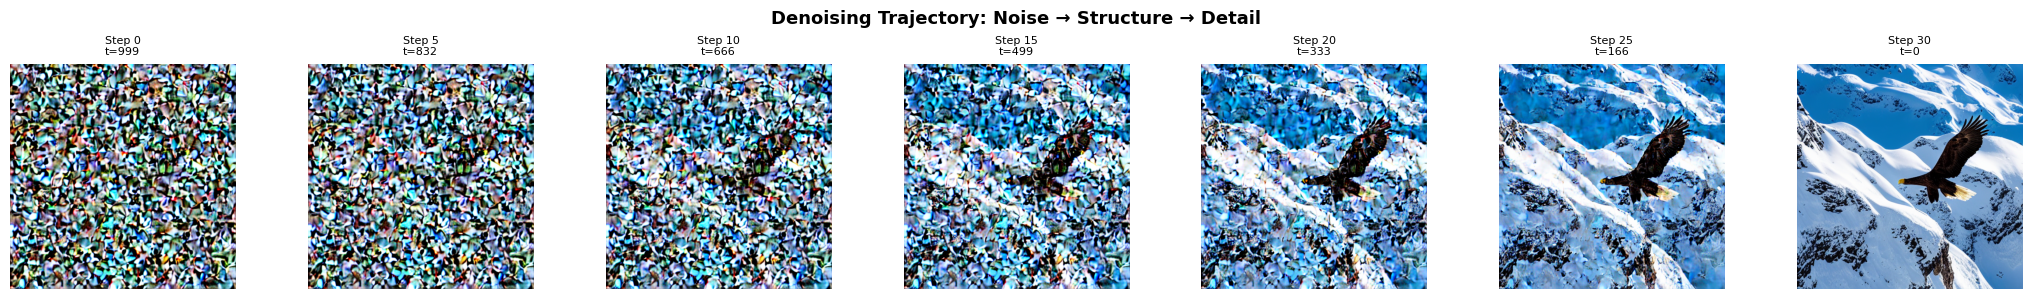


📌 Early steps build global structure; later steps add fine details.


In [10]:
# ── Denoising Trajectory Visualization ─────────────────────────────────────
import torch
from diffusers import StableDiffusionPipeline
import numpy as np

intermediates = []
CAPTURE_EVERY = 5  # capture every N steps

def latent_to_image(latents, vae):
    """Decode latent tensor to PIL image."""
    latents = latents / vae.config.scaling_factor
    with torch.inference_mode():
        decoded = vae.decode(latents).sample
    decoded = (decoded / 2 + 0.5).clamp(0, 1)
    decoded = decoded.cpu().permute(0, 2, 3, 1).numpy()
    return Image.fromarray((decoded[0] * 255).astype(np.uint8))

def capture_callback(pipe, step, timestep, callback_kwargs):
    if step % CAPTURE_EVERY == 0 or step == 0:
        lat = callback_kwargs['latents'].clone()
        img = latent_to_image(lat, pipe.vae)
        intermediates.append((step, timestep.item(), img))
    return callback_kwargs

intermediates.clear()
prompt = "a majestic eagle soaring over snowy mountains, epic landscape photography"
g = torch.Generator(device=device).manual_seed(7)

with torch.inference_mode():
    final = pipe(
        prompt=prompt,
        negative_prompt="blurry, low quality",
        num_inference_steps=30,
        guidance_scale=7.5,
        generator=g,
        callback_on_step_end=capture_callback,
        callback_on_step_end_tensor_inputs=['latents'],
    ).images[0]

# Add final image
intermediates.append((30, 0, final))

# Plot trajectory
imgs   = [x[2] for x in intermediates]
labels = [f'Step {x[0]}\nt={x[1]}' for x in intermediates]

cols = min(len(imgs), 7)
rows = (len(imgs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if len(imgs) > 1 else [axes]

for ax, img, label in zip(axes, imgs, labels):
    ax.imshow(img); ax.set_title(label, fontsize=8); ax.axis('off')
for ax in axes[len(imgs):]: ax.axis('off')

plt.suptitle('Denoising Trajectory: Noise → Structure → Detail',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('denoising_trajectory.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Early steps build global structure; later steps add fine details.")

---
<a name='13-lora'></a>
## 13. Advanced: LoRA and Fine-tuning Concepts

### Why Fine-tune?

Base SD knows millions of concepts, but:
- Can't generate **your specific face** or a **custom product**
- May lack knowledge of **niche artistic styles**
- Prompt-engineering has limits

### LoRA: Low-Rank Adaptation

Full fine-tuning of 860M U-Net params is expensive. LoRA (Hu et al., 2021) decomposes weight updates:

$$W_{\text{new}} = W_0 + \Delta W = W_0 + \underbrace{B \cdot A}_{\text{rank-}r\text{ decomposition}}$$

Where $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times k}$, with $r \ll \min(d, k)$ (typically $r=4$ to $r=64$).

**Result:** Instead of updating $d \times k$ params, only $r(d+k)$ — a **100–1000× reduction**.

### Fine-tuning Methods

| Method | Data needed | Time | Params trained | Use case |
|---|---|---|---|---|
| **DreamBooth** | 5–30 images | ~1h GPU | ~860M (full) | Specific subject/person |
| **LoRA** | 5–100 images | 30min GPU | ~3M | Style, concept |
| **Textual Inversion** | 5–20 images | 1-2h GPU | ~768 (embedding) | New token for concept |

In [ ]:

# Upgrade torchao to resolve incompatibility with peft
!pip install --upgrade torchao>=0.16.0

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
The config attributes {'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  0%|          | 0/4 [00:00<?, ?it/s]

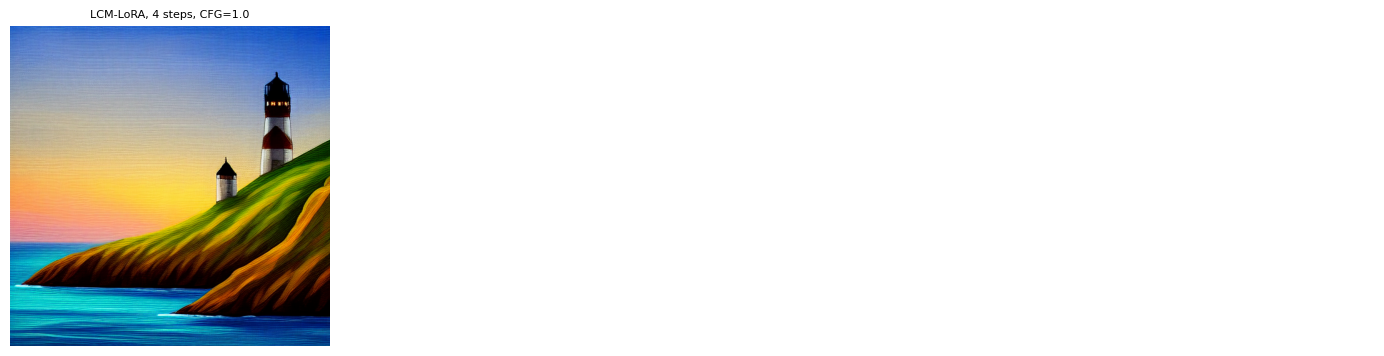

📌 Same base U-Net, 4 steps instead of 25 — the LoRA carries the distillation.

Full linear layer params : 589,824
LoRA (rank=8) params : 12,288
Compression ratio        : 48.0×


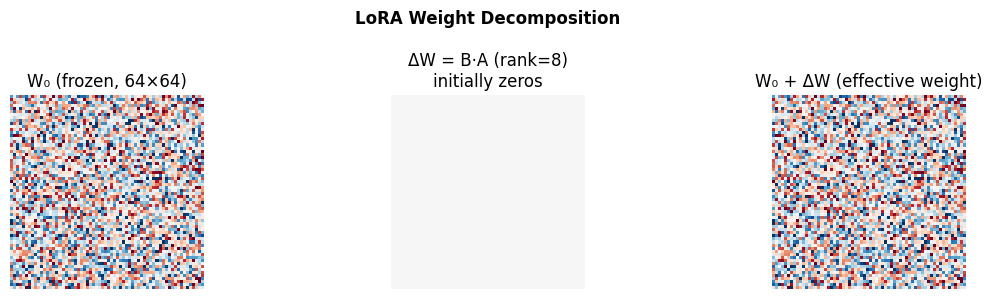

In [12]:
# ── Load a community LoRA from Hugging Face Hub ─────────────────────────────
# LoRAs are small weight delta files (~5-50 MB) that modify the U-Net/text encoder.
# We demonstrate loading one without full fine-tuning.
#
# NOTE: every LoRA method in `diffusers` is guarded by `if not USE_PEFT_BACKEND: raise`,
# and USE_PEFT_BACKEND is only True when `peft>=0.6` imports. That is why `peft` is in
# the install cell of Section 7 — without it this whole section raises a ValueError.

import math
import torch
import torch.nn as nn
from diffusers import LCMScheduler, DPMSolverMultistepScheduler


# Reset the pipeline to base weights first.
# Calling unload_lora_weights() when nothing is loaded is wasteful, so guard it:
if getattr(pipe, "num_fused_loras", 0) or pipe.get_active_adapters():
    pipe.unload_lora_weights()

# ── A real, currently-resolvable SD 1.5 LoRA ────────────────────────────────
# `latent-consistency/lcm-lora-sdv1-5` (verified to resolve on the Hub, 2026-08).
# We drop `weight_name` so diffusers auto-detects the .safetensors file — LoRAs no
# longer ship as .bin, and hardcoding a filename is the usual reason a load fails.
#
# This particular adapter is an *acceleration* LoRA (Latent Consistency Model
# distillation), not a style LoRA: it changes how few steps the model needs, so it
# must be paired with LCMScheduler, ~4-8 steps, and guidance_scale close to 1.
base_scheduler = pipe.scheduler
pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)

g = torch.Generator(device=device).manual_seed(SEED)
with torch.inference_mode():
    lcm_img = pipe(
        prompt="a lighthouse on a cliff at dusk, dramatic sky, digital painting",
        num_inference_steps=4, guidance_scale=1.0, generator=g,
    ).images[0]
show_images([lcm_img], titles=['LCM-LoRA, 4 steps, CFG=1.0'])
print("📌 Same base U-Net, 4 steps instead of 25 — the LoRA carries the distillation.")

# Restore the base pipeline for the sections that follow.
pipe.unload_lora_weights()
pipe.scheduler = base_scheduler

# For a *style* LoRA, browse huggingface.co/models?other=lora&other=stable-diffusion
# or civitai.com and pick one whose base model is SD 1.5, then:
#     pipe.load_lora_weights("<org>/<sd15-style-lora>")
#     pipe.set_adapters(["default_0"], adapter_weights=[0.8])   # scale the effect
# Community LoRA repos disappear often — always check the id resolves before class.

# ── LoRA weight structure (educational) ────────────────────────────────────

class LoRALayer(nn.Module):
    """Minimal LoRA: adds a low-rank branch to an existing linear layer."""
    def __init__(self, original: nn.Linear, rank: int = 4, alpha: float = 1.0):
        super().__init__()
        self.original = original
        self.rank     = rank
        self.scale    = alpha / rank
        d_out, d_in  = original.weight.shape
        # A: standard layer-scale init, std = 1/sqrt(d_in) — like any linear layer,
        #    and crucially independent of `rank`. (Initializing with std = 1/rank
        #    would shrink the effective update quadratically as the rank grows,
        #    which would silently cancel the alpha/rank scaling above.)
        # B: zeros, so ΔW = B·A = 0 at initialization and the adapted model starts
        #    exactly at the pretrained one. ControlNet uses the same trick with
        #    zero-initialized convolutions (Section 14).
        self.lora_A  = nn.Parameter(torch.randn(rank, d_in) / math.sqrt(d_in))
        self.lora_B  = nn.Parameter(torch.zeros(d_out, rank))

    def forward(self, x):
        orig_out = self.original(x)          # W₀ · x
        lora_out = x @ self.lora_A.T @ self.lora_B.T  # (B·A) · x
        return orig_out + self.scale * lora_out

# Show parameter count comparison
d_in, d_out, rank = 768, 768, 8
full_params = d_in * d_out
lora_params = rank * d_in + rank * d_out
print(f"\nFull linear layer params : {full_params:,}")
print(f"LoRA (rank={rank}) params : {lora_params:,}")
print(f"Compression ratio        : {full_params / lora_params:.1f}×")

# Visualize rank-decomposition concept
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
W0 = np.random.randn(64, 64)
A  = np.random.randn(rank, 64) / np.sqrt(64)   # same std = 1/sqrt(d_in) as above
B  = np.zeros((64, rank))
dW = B @ A
axes[0].imshow(W0,      cmap='RdBu_r', vmin=-2, vmax=2); axes[0].set_title('W₀ (frozen, 64×64)'); axes[0].axis('off')
axes[1].imshow(dW,      cmap='RdBu_r', vmin=-0.1, vmax=0.1); axes[1].set_title(f'ΔW = B·A (rank={rank})\ninitially zeros'); axes[1].axis('off')
axes[2].imshow(W0 + dW, cmap='RdBu_r', vmin=-2, vmax=2); axes[2].set_title('W₀ + ΔW (effective weight)'); axes[2].axis('off')
plt.suptitle('LoRA Weight Decomposition', fontweight='bold')
plt.tight_layout(); plt.show()


---
<a name='14-controlnet'></a>
## 14. Practical 6 — ControlNet: structural conditioning

So far we can steer generation with **words** (Sections 8, 11) and with a **starting image**
(Section 9). Neither answers the question every real user asks first:

> *"Keep this exact pose / layout / outline, and change everything else."*

`img2img` cannot do it — `strength` is a single dial that trades *all* structure against
*all* freedom: low strength keeps the colours too, high strength loses the layout. Prompts
cannot do it either; 77 tokens of English will not specify where a hand goes.

**ControlNet** (Zhang, Rao & Agrawala, ICCV 2023, arXiv 2302.05543) adds a *second*
conditioning channel alongside the text one: a spatial map — Canny edges, a depth map, a
human pose skeleton, a segmentation mask — that constrains geometry pixel-by-pixel while
the prompt keeps full control of content and style.

This connects directly back to the earlier classes: the Canny edge detector and the
monocular depth maps we produced there were *outputs* then. Here they become *inputs*.

### 14.1 The mechanism

Fine-tuning the whole U-Net on (edge map, image) pairs would work, but it needs a large
dataset and it destroys the base model — you get one specialized checkpoint per condition
type. ControlNet avoids both problems with a copy-and-inject design:

```text
        text c ───────────────────────┐
                                      ▼
  z_t ──►┌──────────────────────────────────┐
         │  FROZEN SD U-Net encoder          │──skip──►┌───────────────┐
         │  (weights unchanged, forever)     │         │ FROZEN decoder│──► ε̂
         └──────────────────────────────────┘    ▲    └───────────────┘
                                                 │ (+)
  hint  ──►[zero conv]──►┌─────────────────────┐ │
 (edges)                 │ TRAINABLE COPY of   │─┘  each resolution's output passes
                         │ the encoder+mid     │    through its own [zero conv]
                         └─────────────────────┘
```

1. **Freeze** the original U-Net. It is never updated, so the base model's knowledge — and
   every LoRA and prompt trick built on it — survives intact.
2. **Clone** the U-Net's encoder blocks and middle block into a **trainable copy**. It
   starts from the pretrained weights, so it is not learning vision from scratch; it only
   has to learn how to read the hint.
3. Feed the spatial hint into the copy, and add the copy's output back into the frozen
   decoder's skip connections **through 1×1 convolutions whose weights and biases are
   initialized to zero** ("zero convolutions").

### 14.2 Why zero-initialized convolutions — the same trick as LoRA's **B**

At step 0 the zero convs output exactly zero, so the injected term is zero and the whole
network computes **bit-for-bit what the base SD computed**. Training therefore starts from
a working model rather than from a corrupted one, and there is no early phase in which
random noise from an untrained branch destroys the pretrained features.

That is precisely the argument for initializing LoRA's $B$ matrix to zeros in Section 13:
$\Delta W = B \cdot A = 0$ at init, so the adapted model *is* the pretrained model, and the
adapter can only ever add to it. Both designs place a zero-valued gate between new
parameters and a frozen backbone. Note the asymmetry in both cases — one factor is zero and
the *other* is randomly initialized. If both were zero the gradient would be identically
zero and nothing would ever train.

A zero conv is not stuck at zero, incidentally: its gradient with respect to its weights is
proportional to its (non-zero) input, so the weights move off zero on the very first step.

### 14.3 Practical notes

| | |
|---|---|
| Cost | one extra trainable copy of the U-Net **encoder + middle block** — the code cell below prints the exact parameter count next to the U-Net's |
| Memory | fits comfortably in a T4's 16 GB alongside SD 1.5 in fp16 |
| Base model | ControlNets are tied to a base: an SD 1.5 ControlNet will not load into SDXL or SD 3 |
| Composability | several ControlNets can be stacked (pass a list) with per-net weights |
| Main knob | `controlnet_conditioning_scale` (default 1.0) — lower it when the hint fights the prompt |

Available SD 1.5 conditions from `lllyasviel/*` include `canny`, `depth`, `openpose`,
`seg`, `normal`, `mlsd`, `scribble` and `hed`. We use Canny because we can compute the hint
with three lines of OpenCV and no extra model download.

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

U-Net (frozen)     : 860M params
ControlNet (added) : 361M params (42% of the U-Net)
VRAM allocated     : 2.90 GB


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

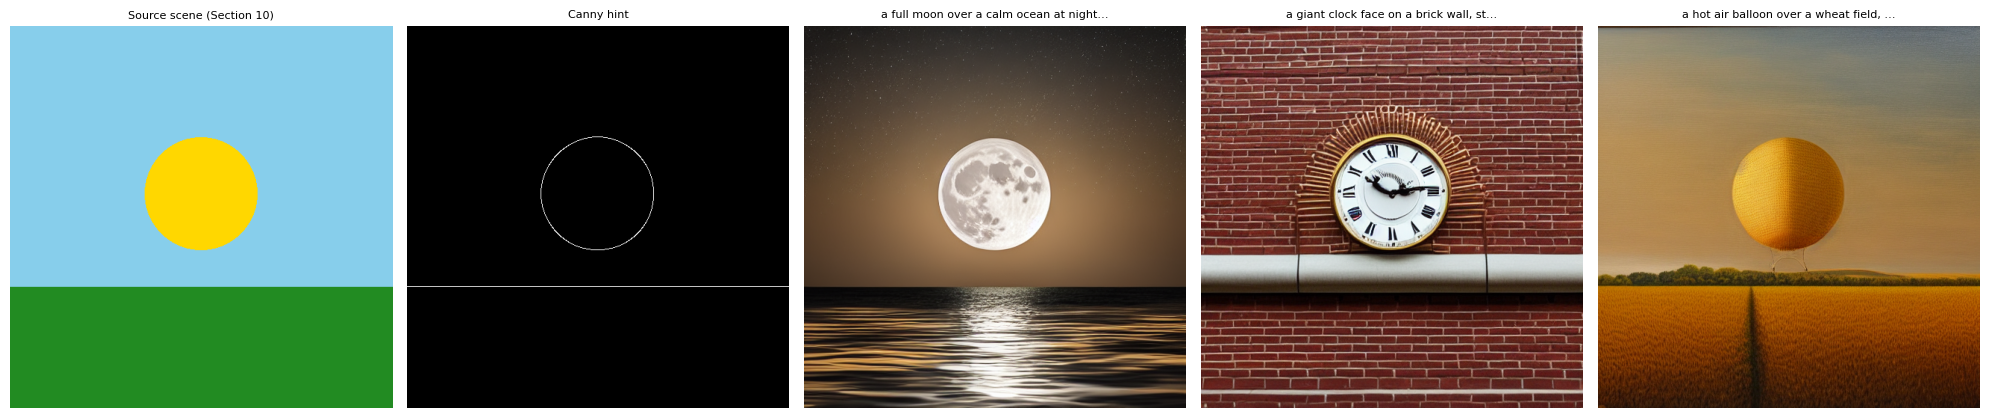


📌 One edge map, three prompts: the circle stays a circle and the horizon stays
   where it was, while the *content* is entirely re-imagined each time. Compare with
   Practical 2 (img2img), where keeping the layout also meant keeping the colours.

   Things to try:
   • controlnet_conditioning_scale = 0.4 → the hint becomes a suggestion
   • controlnet_conditioning_scale = 1.6 → edges dominate, prompt fidelity drops
   • cv2.Canny thresholds (50,150) vs (150,250) → denser vs sparser structure
   • swap in 'lllyasviel/sd-controlnet-openpose' with a pose skeleton as the hint


In [13]:
# ── ControlNet (Canny) on the synthetic scene from Practical 3 ──────────────
import cv2                      # preinstalled on Colab
import numpy as np
import torch
from PIL import Image
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline

# ── 1. Build the control hint: Canny edges of `scene` (defined in Section 10) ──
# The hint must be a 3-channel image at the generation resolution. Canny returns a
# single-channel uint8 map, so we stack it to RGB.
scene_np = np.array(scene)
edges    = cv2.Canny(scene_np, 100, 200)          # low / high hysteresis thresholds
canny_image = Image.fromarray(np.stack([edges] * 3, axis=-1))

# ── 2. Load the ControlNet and attach it to the pipeline we already have ──────
# Building the pipeline from the *components* of `pipe` means the VAE, U-Net, CLIP
# text encoder and tokenizer are reused from GPU memory — only the ControlNet is
# downloaded (~1.4 GB) and only its weights are new.
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny", torch_dtype=dtype
)

cn_pipe = StableDiffusionControlNetPipeline(
    vae=pipe.vae,
    text_encoder=pipe.text_encoder,
    tokenizer=pipe.tokenizer,
    unet=pipe.unet,                 # frozen, shared — ControlNet does not modify it
    controlnet=controlnet,
    scheduler=pipe.scheduler,
    safety_checker=None,
    feature_extractor=None,
    requires_safety_checker=False,
).to(device)

unet_params = sum(p.numel() for p in pipe.unet.parameters())
cn_params   = sum(p.numel() for p in controlnet.parameters())
print(f"U-Net (frozen)     : {unet_params / 1e6:.0f}M params")
print(f"ControlNet (added) : {cn_params / 1e6:.0f}M params "
      f"({100 * cn_params / unet_params:.0f}% of the U-Net)")
if device == 'cuda':
    print(f"VRAM allocated     : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# ── 3. Three different prompts, ONE edge map ──────────────────────────────────
# Same geometry every time — a disc above a horizon — completely different content.
# This is the whole point: structure comes from the hint, content from the prompt.
prompts = [
    "a full moon over a calm ocean at night, moonlight reflection, photorealistic",
    "a giant clock face on a brick wall, steampunk, brass and copper, intricate gears",
    "a hot air balloon over a wheat field, golden hour, oil painting",
]

outputs, titles = [scene, canny_image], ['Source scene (Section 10)', 'Canny hint']
for p in prompts:
    g = torch.Generator(device=device).manual_seed(SEED)
    with torch.inference_mode():
        img = cn_pipe(
            prompt=p,
            image=canny_image,                    # the control hint, NOT an init image
            negative_prompt="blurry, low quality, watermark, text",
            num_inference_steps=25,
            guidance_scale=7.5,
            controlnet_conditioning_scale=1.0,    # try 0.5 and 1.5 to feel the trade-off
            generator=g,
        ).images[0]
    outputs.append(img)
    titles.append(p[:38] + '…')

show_images(outputs, titles=titles, cols=5, figsize=(20, 4.5))

print("\n📌 One edge map, three prompts: the circle stays a circle and the horizon stays")
print("   where it was, while the *content* is entirely re-imagined each time. Compare with")
print("   Practical 2 (img2img), where keeping the layout also meant keeping the colours.")
print("\n   Things to try:")
print("   • controlnet_conditioning_scale = 0.4 → the hint becomes a suggestion")
print("   • controlnet_conditioning_scale = 1.6 → edges dominate, prompt fidelity drops")
print("   • cv2.Canny thresholds (50,150) vs (150,250) → denser vs sparser structure")
print("   • swap in 'lllyasviel/sd-controlnet-openpose' with a pose skeleton as the hint")

# Free the ControlNet if you need the VRAM back for later experiments:
# del cn_pipe, controlnet; torch.cuda.empty_cache()

---
<a name='15-exercises'></a>
## 15. Exercises

### 🟢 Beginner

**Exercise 1 — Prompt Ablation**  
Pick a subject and generate 6 images with progressively richer prompts (bare noun → full richly-described prompt + negative). Create a figure comparing quality.

**Exercise 2 — Scheduler Comparison**  
Replace the scheduler with: `DDIMScheduler`, `PNDMScheduler`, `EulerAncestralDiscreteScheduler`, `DPMSolverMultistepScheduler`. Fix seed and prompt. Show all outputs with step counts and measure generation time.

```python
from diffusers import DDIMScheduler, PNDMScheduler, EulerAncestralDiscreteScheduler
# Your code here
```

---

### 🟡 Intermediate

**Exercise 3 — Noise Schedule from Scratch**  
Implement the `forward_diffusion` function and apply it to an MNIST digit. Plot the signal-to-noise ratio (SNR = $\bar{\alpha}_t / (1 - \bar{\alpha}_t)$) in dB for both linear and cosine schedules.

**Exercise 4 — DDIM Sampler**  
Implement DDIM sampling manually using the formula from Section 6, operating on random latents and using the pipeline's U-Net. Compare 10, 25, 50 step outputs.

---

### 🔴 Advanced

**Exercise 5 — Attention Map Visualization**  
Register forward hooks on the U-Net's cross-attention layers. For a given prompt, capture and visualize the attention maps for individual tokens (e.g., show which image regions attend to "mountain", "sky", "eagle").

**Exercise 6 — Minimal DDPM Training**  
Train a tiny DDPM on MNIST (or Fashion-MNIST) from scratch using the `ResBlock` and `SinusoidalPositionEmbedding` classes from Section 4. Show the training loss curve and generated samples every 5 epochs.

```python
# Skeleton:
class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_mlp = SinusoidalPositionEmbedding(128)
        # TODO: add encoder, bottleneck, decoder

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        # TODO: forward pass
        pass

def training_loop(model, dataloader, optimizer, T=1000, epochs=50):
    betas, alphas, alphas_bar = get_noise_schedule(T)
    ab = torch.from_numpy(alphas_bar).float().to(device)
    for epoch in range(epochs):
        for batch, _ in dataloader:
            x0 = batch.to(device)
            t  = torch.randint(0, T, (x0.shape[0],), device=device)
            eps = torch.randn_like(x0)
            xt = torch.sqrt(ab[t])[:,None,None,None] * x0 + \
                 torch.sqrt(1 - ab[t])[:,None,None,None] * eps
            pred_eps = model(xt, t)
            loss = F.mse_loss(pred_eps, eps)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
```

**Exercise 7 — Measure prompt quality instead of eyeballing it (CLIPScore)**

Section 11 compared four prompting strategies by looking at four images. That is not
evidence: with one seed per strategy you cannot separate "the prompt was better" from
"that seed happened to be luckier". This exercise replaces the impression with a number.

**CLIPScore** (Hessel et al., 2021) is the standard reference-free metric for
text-to-image alignment. It embeds the image and the prompt with a CLIP model and
reports the rescaled cosine similarity:

$$\text{CLIPScore}(x, c) = \max\big(100 \cdot \cos(E_I(x),\, E_T(c)),\ 0\big)$$

Use a CLIP checkpoint that is **not** the one inside the pipeline
(`openai/clip-vit-base-patch32`, not the ViT-L/14 text tower SD 1.5 conditions on) —
scoring a generation with the very encoder that guided it flatters the result.

```python
# ── CLIPScore helper ────────────────────────────────────────────────────────
import torch, numpy as np
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

@torch.no_grad()
def clipscore(images, prompts):
    """Rescaled CLIP cosine similarity, one score per (image, prompt) pair."""
    if isinstance(prompts, str):
        prompts = [prompts] * len(images)
    batch = clip_proc(text=prompts, images=images, return_tensors="pt",
                      padding=True, truncation=True).to(device)
    img_e = clip_model.get_image_features(pixel_values=batch["pixel_values"])
    txt_e = clip_model.get_text_features(input_ids=batch["input_ids"],
                                         attention_mask=batch["attention_mask"])
    img_e = img_e / img_e.norm(dim=-1, keepdim=True)
    txt_e = txt_e / txt_e.norm(dim=-1, keepdim=True)
    return (100.0 * (img_e * txt_e).sum(-1)).clamp(min=0).float().cpu().numpy()
```

**Your task**

1. For each of the four strategies in Section 11 (`Minimal`, `Medium`, `Rich`,
   `With Negative`), generate **20 images**: 4 subjects × 5 seeds, so that neither the
   subject nor the seed is confounded with the strategy.
2. Score every image against **the same evaluation caption** — a plain description of the
   intended subject (e.g. `"a robot in a garden"`). Scoring each image against its own
   long prompt measures prompt length, not fidelity.
3. Report `mean ± std` per strategy and plot the four means with error bars.
4. Answer in writing: does the gap between `Rich` and `Medium` exceed the spread across
   seeds *within* either group? If it does not, the ranking is not supported by the data.

**Things the metric will not tell you.** CLIPScore is reference-free, so it rewards
semantic presence, not anatomy, composition or aesthetics — an image with six fingers can
outscore a clean one. It also saturates: past a point, adding quality tokens changes the
picture without changing the score. Distributional metrics (FID, KID) need hundreds of
images and a reference set, which is why they do not fit in a class notebook. Report
CLIPScore as *alignment*, never as *quality*.


---
<a name='16-responsible-use'></a>
## 16. What we switched off, and what we borrowed

Three lines in this notebook have consequences outside it. They are worth understanding as
engineering facts, in the same way you understand what `weights_only=False` does to
`torch.load`.

### 16.1 `safety_checker=None` — what it actually disables

Every pipeline in this notebook is loaded with `safety_checker=None`. That flag does not
change generation at all: the U-Net, the scheduler and the sampled image are byte-identical
with or without it. What it removes is a **post-hoc classifier applied to the finished
image**, `CompVis/stable-diffusion-safety-checker` — a CLIP ViT-L/14 image encoder plus a
small head that compares the image embedding against a set of fixed "unsafe concept"
embeddings, and blanks the output to a black image when the cosine similarity crosses a
threshold.

Why the course turns it off:

- it loads a **second full CLIP image tower** that the pipeline otherwise never needs, and
  runs it on every generated image;
- it is a blunt threshold classifier with well-documented false positives — landscapes,
  medical illustrations and skin-toned surfaces get blanked — and a black square in the
  middle of a comparison grid teaches nothing;
- it inspects only the *output*, so it is not a safety property of the model; the model
  itself is unchanged either way.

Why you should think twice before copying that line into anything with users: the filter is
the only thing standing between a text box and the model's full output distribution.
Disabling it is defensible in a controlled classroom with synthetic prompts; anywhere else
it is a deliberate product decision, and "I copied it from a tutorial" is not a design
rationale. If you ship a generation feature, either keep the checker or replace it with
something better — and record the decision.

### 16.2 Where "by Greg Rutkowski" gets its power

SD 1.5 was trained on **LAION-5B**, ~5.85 billion image–text pairs harvested from Common
Crawl. It is a dataset of *URLs and alt-text*, not of licensed images: inclusion required no
permission from, notification to, or payment to the people who made the images. Living
artists are in it in volume, which is precisely why appending a name to a prompt works — the
model has seen many captioned examples of that style.

Facts worth knowing rather than arguing about:

- **Style itself is generally not copyrightable**, but the training-time copies and the
  outputs are contested separately; litigation brought by artists and stock-image holders
  against image-model vendors has been running since 2023 and the law is not settled.
- **LAION-5B was withdrawn in December 2023** after Stanford's Internet Observatory
  identified known CSAM among the scraped URLs; a cleaned Re-LAION followed in 2024. SD 1.5
  was trained before that cleaning. This is not a hypothetical provenance concern — it is
  the documented history of the weights running in this notebook.
- **Opt-out arrived after the fact.** Stability began honouring Spawning's *Have I Been
  Trained?* opt-out list with SD 3; nothing retroactively removes an artist from SD 1.5.

Practical consequence: using artist-name prompting to *study* how CLIP conditioning encodes
style is a legitimate research and teaching use — that is what Section 11 does. Treat it
differently once the output is a commercial deliverable, and if you are building a product,
prefer models whose training-data provenance you can actually state (licensed corpora, or
your own fine-tune on data you hold rights to).

### 16.3 Saying "this was generated" — C2PA and watermarking

Two complementary mechanisms exist, and they fail in different ways.

**C2PA / Content Credentials** (Coalition for Content Provenance and Authenticity; the
specification is also published as an ISO standard) attaches a **cryptographically signed
manifest** to the file: which tool produced it, from which inputs, with which edits, signed
by a certificate chain. It is precise and auditable — and it is *metadata*, so a screenshot,
a re-encode, or `exiftool -all=` removes it. It proves provenance when present; its absence
proves nothing.

**Invisible watermarking** embeds the signal in the pixels, so it survives screenshots,
cropping and re-compression. `diffusers` ships an `invisible-watermark`-based watermarker
and applies it by default in the SDXL pipelines; the original SD reference implementation
did the same, and it is one of the things a bare `StableDiffusionPipeline` does **not** do —
so nothing you generated above is marked. Google's SynthID is the same idea at production
scale. Watermarks survive ordinary handling but are removable by a determined adversary, and
detection is usually vendor-side.

Neither is a content filter, and neither answers "is this true?". They answer the narrower,
tractable question: *where did this file come from?* The direction of travel is regulatory
rather than voluntary — the **EU AI Act, Article 50** obliges providers of generative
systems to mark synthetic output in a machine-readable form.

**Exercise 8 (short).** Save one image from Practical 1 and inspect its metadata (`exiftool`,
or `PIL.Image.open(path).info`). Nothing in it says a machine made it. Now write the few
lines of `PngInfo` that would at least record the model id, prompt, seed and scheduler — and
then explain in one sentence why that is *not* equivalent to a signed C2PA manifest.

---
<a name='17-references'></a>
## 17. References

1. Ho et al. (2020). *Denoising Diffusion Probabilistic Models*. [arXiv:2006.11239](https://arxiv.org/abs/2006.11239)
2. Song et al. (2020). *Denoising Diffusion Implicit Models*. [arXiv:2010.02502](https://arxiv.org/abs/2010.02502)
3. Rombach et al. (2022). *High-Resolution Image Synthesis with Latent Diffusion Models*. [arXiv:2112.10752](https://arxiv.org/abs/2112.10752)
4. Radford et al. (2021). *Learning Transferable Visual Models From Natural Language Supervision* (CLIP). [arXiv:2103.00020](https://arxiv.org/abs/2103.00020)
5. Ho & Salimans (2022). *Classifier-Free Diffusion Guidance*. [arXiv:2207.12598](https://arxiv.org/abs/2207.12598)
6. Hu et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
7. Nichol & Dhariwal (2021). *Improved Denoising Diffusion Probabilistic Models*. [arXiv:2102.09672](https://arxiv.org/abs/2102.09672)
8. Zhang, Rao & Agrawala (2023). *Adding Conditional Control to Text-to-Image Diffusion Models* (ControlNet). [arXiv:2302.05543](https://arxiv.org/abs/2302.05543)
9. Esser et al. (2024). *Scaling Rectified Flow Transformers for High-Resolution Image Synthesis* (SD 3). [arXiv:2403.03206](https://arxiv.org/abs/2403.03206)
10. Luo et al. (2023). *LCM-LoRA: A Universal Stable-Diffusion Acceleration Module*. [arXiv:2311.05556](https://arxiv.org/abs/2311.05556)
11. Hessel et al. (2021). *CLIPScore: A Reference-free Evaluation Metric for Image Captioning*. [arXiv:2104.08718](https://arxiv.org/abs/2104.08718)
12. Schuhmann et al. (2022). *LAION-5B: An Open Large-Scale Dataset for Training Next Generation Image-Text Models*. [arXiv:2210.08402](https://arxiv.org/abs/2210.08402)
13. Kingma & Welling (2019). *An Introduction to Variational Autoencoders*. [arXiv:1906.02691](https://arxiv.org/abs/1906.02691)
14. Goodfellow et al. (2014). *Generative Adversarial Nets*. [arXiv:1406.2661](https://arxiv.org/abs/1406.2661)
15. 🤗 Diffusers documentation: [huggingface.co/docs/diffusers](https://huggingface.co/docs/diffusers)
16. Weighted prompts with `prompt_embeds` (`sd_embed`): [diffusers guide](https://huggingface.co/docs/diffusers/main/en/using-diffusers/weighted_prompts)
17. C2PA Content Credentials specification: [c2pa.org/specifications](https://c2pa.org/specifications/)
18. EU AI Act, Article 50 — transparency obligations for generative systems: [artificialintelligenceact.eu/article/50](https://artificialintelligenceact.eu/article/50/)